# MNIST Classification with SVM

## Imports

Import all required libraries for data loading, model training, evaluation, and visualization.

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

## Data Loading & Preprocessing

Load the MNIST dataset via `fetch_openml`, downsample to 5,000 samples for faster SVM training, split 80/20 into train and test sets, then scale pixel values using `StandardScaler`.

In [8]:
# Load MNIST
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X, y = mnist.data, mnist.target

# Downsample to 5,000 samples
rng = np.random.default_rng(42)
indices = rng.choice(len(X), size=5000, replace=False)
X, y = X[indices], y[indices]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4000, 784), Test: (1000, 784)


## Data Visualization

Display a sample of 10 images from the dataset to verify the data loaded correctly and get a feel for the digit classes.

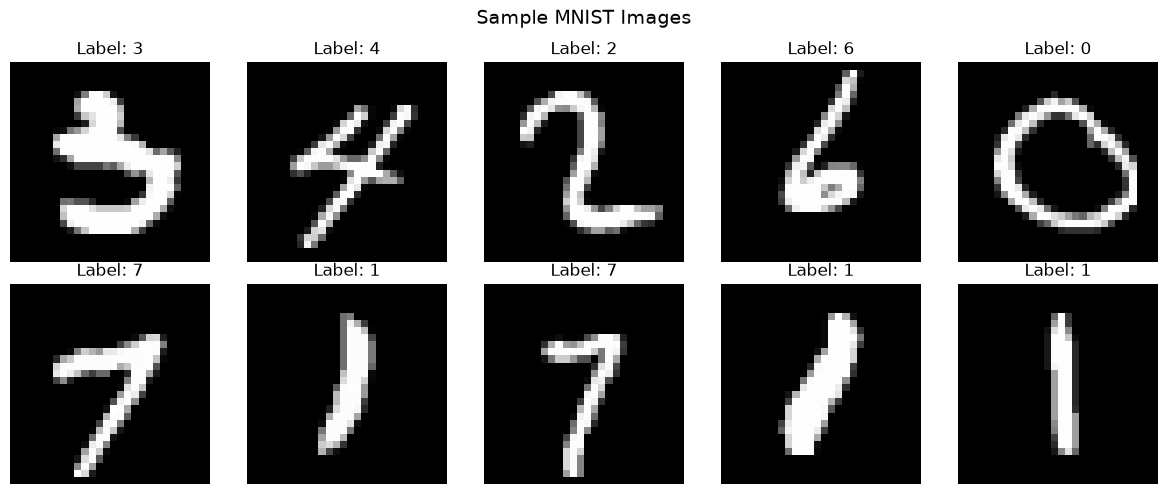

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample MNIST Images", fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Hyperparameter Tuning

tuning c and gamma values to get optimal performance out of the svm model

In [10]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
}

grid_search = GridSearchCV(
    SVC(kernel="rbf", random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
)
grid_search.fit(X_train, y_train)

print(f"Best C:     {grid_search.best_params_['C']}")
print(f"Best gamma: {grid_search.best_params_['gamma']}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best C:     10
Best gamma: 0.001
Best CV accuracy: 0.9185


## Model Training

Train an SVM classifier with an RBF kernel on the scaled training data, then generate predictions on the test set.

In [29]:
svm_model = grid_search.best_estimator_
print(
    f"Training with C={grid_search.best_params_['C']}, gamma={grid_search.best_params_['gamma']}"
)

print("Making predictions")
y_pred = svm_model.predict(X_test)

Training with C=10, gamma=0.001
Making predictions


## Evaluation

Compute accuracy, precision, and recall on the test set, then plot a confusion matrix to see which digits the model confuses most.


--- Final Evaluation Metrics ---
Accuracy:  0.9260
Precision: 0.9275
Recall:    0.9265

--- Class-wise Report ---
              precision    recall  f1-score   support

           0     0.9519    0.9802    0.9659       101
           1     0.9714    0.9623    0.9668       106
           2     0.8738    0.9278    0.9000        97
           3     0.8879    0.8559    0.8716       111
           4     0.9286    0.9286    0.9286        98
           5     0.9062    0.9560    0.9305        91
           6     0.9884    0.9341    0.9605        91
           7     0.8957    0.9450    0.9196       109
           8     0.9444    0.8673    0.9043        98
           9     0.9271    0.9082    0.9175        98

    accuracy                         0.9260      1000
   macro avg     0.9275    0.9265    0.9265      1000
weighted avg     0.9269    0.9260    0.9259      1000



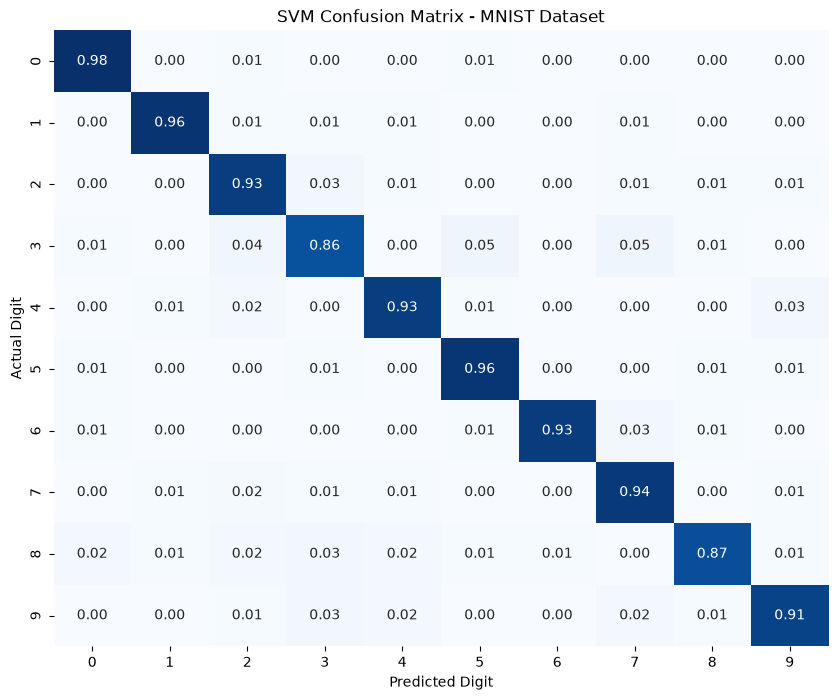

In [30]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

print("\n--- Final Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

print("\n--- Class-wise Report ---")
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix - SVM
cm = confusion_matrix(y_test, y_pred, normalize="true")
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False)
plt.title("SVM Confusion Matrix - MNIST Dataset")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.show()

## SVM (RBF, No Tuning)

Default RBF SVM with C=1.0 to show the baseline before hyperparameter tuning.

In [31]:
svm_default = SVC(kernel="rbf", random_state=42)
svm_default.fit(X_train, y_train)
y_pred_default = svm_default.predict(X_test)

print("--- SVM (RBF, Default C=1.0) Classification Report ---")
print(classification_report(y_test, y_pred_default, digits=4))

--- SVM (RBF, Default C=1.0) Classification Report ---
              precision    recall  f1-score   support

           0     0.9800    0.9703    0.9751       101
           1     0.9806    0.9528    0.9665       106
           2     0.7826    0.9278    0.8491        97
           3     0.8857    0.8378    0.8611       111
           4     0.9091    0.9184    0.9137        98
           5     0.8901    0.8901    0.8901        91
           6     0.9425    0.9011    0.9213        91
           7     0.8583    0.9450    0.8996       109
           8     0.9432    0.8469    0.8925        98
           9     0.9022    0.8469    0.8737        98

    accuracy                         0.9040      1000
   macro avg     0.9074    0.9037    0.9043      1000
weighted avg     0.9074    0.9040    0.9044      1000



## SVM (Linear Kernel)

SVM without the RBF kernel 

In [20]:
svm_linear = SVC(kernel="linear", random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

print("--- SVM (Linear) Classification Report ---")
print(classification_report(y_test, y_pred_linear, digits=4))

--- SVM (Linear) Classification Report ---
              precision    recall  f1-score   support

           0     0.9327    0.9604    0.9463       101
           1     0.9626    0.9717    0.9671       106
           2     0.8241    0.9175    0.8683        97
           3     0.8545    0.8468    0.8507       111
           4     0.8182    0.9184    0.8654        98
           5     0.8750    0.9231    0.8984        91
           6     0.9551    0.9341    0.9444        91
           7     0.9600    0.8807    0.9187       109
           8     0.9111    0.8367    0.8723        98
           9     0.8837    0.7755    0.8261        98

    accuracy                         0.8960      1000
   macro avg     0.8977    0.8965    0.8958      1000
weighted avg     0.8983    0.8960    0.8958      1000



## Naive Bayes


In [16]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("--- Naive Bayes Classification Report ---")
print(classification_report(y_test, y_pred_nb, digits=4))

--- Naive Bayes Classification Report ---
              precision    recall  f1-score   support

           0     0.7475    0.7327    0.7400       101
           1     0.7557    0.9340    0.8354       106
           2     0.7561    0.3196    0.4493        97
           3     0.6596    0.2793    0.3924       111
           4     0.7931    0.2347    0.3622        98
           5     0.4615    0.0659    0.1154        91
           6     0.5503    0.9011    0.6833        91
           7     0.8431    0.3945    0.5375       109
           8     0.2632    0.7143    0.3846        98
           9     0.4770    0.8469    0.6103        98

    accuracy                         0.5420      1000
   macro avg     0.6307    0.5423    0.5110      1000
weighted avg     0.6364    0.5420    0.5147      1000



## Decision Tree


In [28]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt, digits=4))

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0     0.8265    0.8020    0.8141       101
           1     0.9159    0.9245    0.9202       106
           2     0.6698    0.7320    0.6995        97
           3     0.6529    0.7117    0.6810       111
           4     0.7826    0.7347    0.7579        98
           5     0.7143    0.7692    0.7407        91
           6     0.7753    0.7582    0.7667        91
           7     0.9300    0.8532    0.8900       109
           8     0.6939    0.6939    0.6939        98
           9     0.7473    0.6939    0.7196        98

    accuracy                         0.7690      1000
   macro avg     0.7708    0.7673    0.7684      1000
weighted avg     0.7729    0.7690    0.7702      1000



## MLP (Multi-Layer Perceptron)


In [26]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128), max_iter=30, random_state=42, verbose=True
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("--- MLP Classification Report ---")
print(classification_report(y_test, y_pred_mlp, digits=4))

Iteration 1, loss = 1.01628353
Iteration 2, loss = 0.28912706
Iteration 3, loss = 0.16540169
Iteration 4, loss = 0.10263379
Iteration 5, loss = 0.06848407
Iteration 6, loss = 0.04491821
Iteration 7, loss = 0.03080655
Iteration 8, loss = 0.02091312
Iteration 9, loss = 0.01531116
Iteration 10, loss = 0.01144584
Iteration 11, loss = 0.00935807
Iteration 12, loss = 0.00744505
Iteration 13, loss = 0.00638120
Iteration 14, loss = 0.00532341
Iteration 15, loss = 0.00449794
Iteration 16, loss = 0.00401756
Iteration 17, loss = 0.00352948
Iteration 18, loss = 0.00311456
Iteration 19, loss = 0.00278041
Iteration 20, loss = 0.00250229
Iteration 21, loss = 0.00227983
Iteration 22, loss = 0.00209112
Iteration 23, loss = 0.00191005
Iteration 24, loss = 0.00175488
Iteration 25, loss = 0.00162923
Iteration 26, loss = 0.00151122
Iteration 27, loss = 0.00140928
Iteration 28, loss = 0.00131903
Iteration 29, loss = 0.00123677
Iteration 30, loss = 0.00116659
--- MLP Classification Report ---
              p

c:\Users\lenovo\Desktop\Arbisoft\week1\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


## Classifier Comparison

macro F1 scores across all classifiers. The best performing model is highlighted in green.

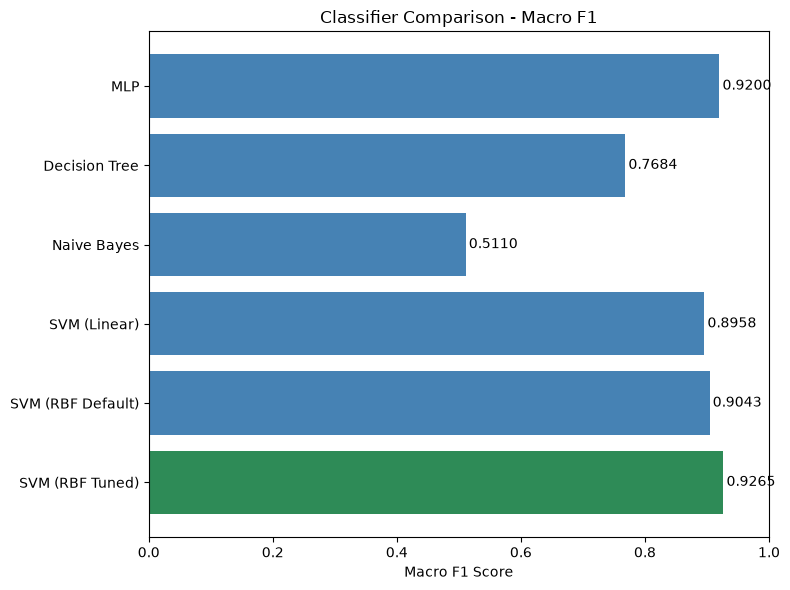

In [32]:
results = {
    "SVM (RBF Tuned)": f1_score(y_test, y_pred, average="macro"),
    "SVM (RBF Default)": f1_score(y_test, y_pred_default, average="macro"),
    "SVM (Linear)": f1_score(y_test, y_pred_linear, average="macro"),
    "Naive Bayes": f1_score(y_test, y_pred_nb, average="macro"),
    "Decision Tree": f1_score(y_test, y_pred_dt, average="macro"),
    "MLP": f1_score(y_test, y_pred_mlp, average="macro"),
}

names = list(results.keys())
scores = list(results.values())
colors = [
    "seagreen" if n == max(results, key=results.get) else "steelblue" for n in names
]

plt.figure(figsize=(8, 6))
bars = plt.barh(names, scores, color=colors)
plt.xlabel("Macro F1 Score")
plt.title("Classifier Comparison - Macro F1")
plt.xlim(0, 1)
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.4f}",
        va="center",
    )
plt.tight_layout()
plt.show()

## Analysis

Across all classifiers, the tuned SVM with RBF kernel performs best on this dataset.

The MLP is a close second  With no hyperparameter tuning it already matches the tuned SVM closely. 

Decision Tree and Naive Bayes fall well behind, proving to be too simplistic for image classification.